### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
pd.set_option("display.max_colwidth",None)
warnings.filterwarnings("ignore")

### Import Raw Data

In [6]:
df=pd.read_excel("Grocery.xlsx")

### Sample Data

In [8]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [9]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


### Size of Data

In [14]:
print("Size of data: ",df.shape)

Size of data:  (8523, 12)


### Field Information

In [17]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [19]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### Data Cleaning

In [22]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [24]:
df["Item Fat Content"].replace({"LF":"Low Fat","reg":"Regular","low fat":"Low Fat"},inplace=True)

In [26]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat'], dtype=object)

### Business Requirement

### KPI Requirement

In [30]:
# Total Sales
total_sales=df["Sales"].sum()

# Average sales
avg_sales=df["Sales"].mean()

# No of item sold
no_of_item_sold= df["Sales"].count()

# Average rating 

Avg_rating=df["Rating"].mean()

In [32]:
# Display

print(f"Total Sales:${total_sales:,.2f}")
print(f"Average Sales:${avg_sales:.0f}")
print(f"Total Items:{no_of_item_sold:,}")
print(f"Average Ranking:{Avg_rating:.1f}")

Total Sales:$1,201,681.49
Average Sales:$141
Total Items:8,523
Average Ranking:4.0


### Chart Requirement

In [35]:
sales_by_fat=df.groupby("Item Fat Content")["Sales"].sum().to_frame()

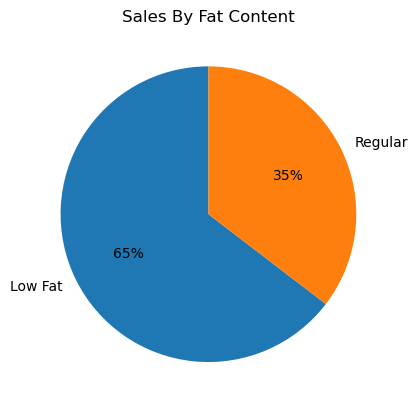

In [37]:
plt.pie(x=sales_by_fat["Sales"],labels=sales_by_fat.index,autopct="%.f%%",startangle=90)
plt.title("Sales By Fat Content")
plt.show()

### Total Sales By Item types

In [44]:
sales_by_type=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)

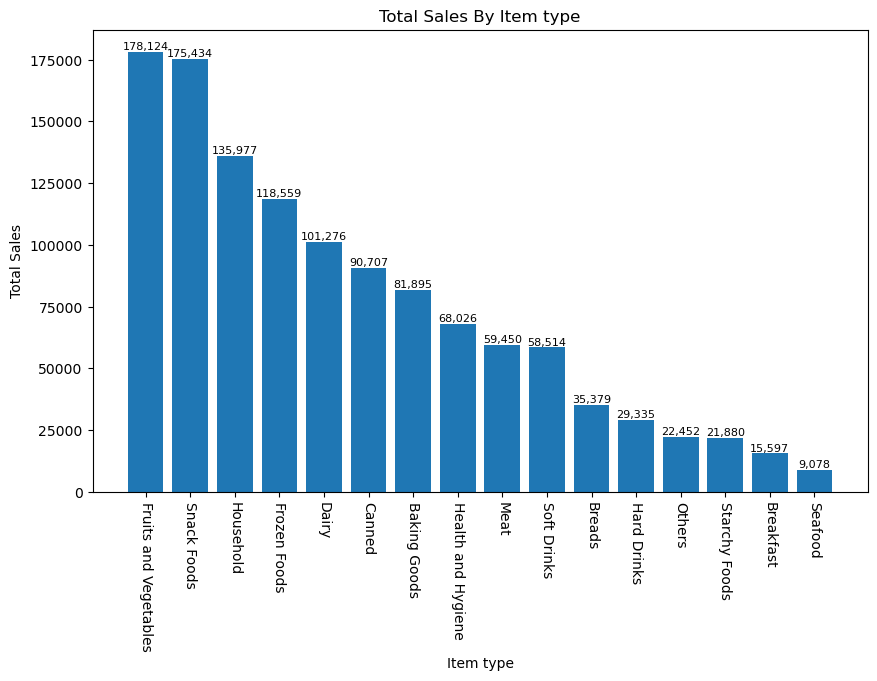

In [52]:
plt.figure(figsize=(10,6))
bars=plt.bar(x=sales_by_type.index,height=sales_by_type)
plt.xticks(rotation=-90)
plt.xlabel("Item type")
plt.ylabel("Total Sales")
plt.title("Total Sales By Item type")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() /2,bar.get_height(),
             f'{bar.get_height():,.0f}',ha="center",va="bottom",fontsize=8)
    
plt.show()

### Fat Content by Outlet for Total Sales

In [93]:
ax=df.pivot_table(index="Outlet Location Type",columns="Item Fat Content",values="Sales",aggfunc="sum")
ax

Item Fat Content,Low Fat,Regular
Outlet Location Type,,
Tier 1,215047.9126,121349.8994
Tier 2,254464.7794,138685.8682
Tier 3,306806.9964,165326.0368


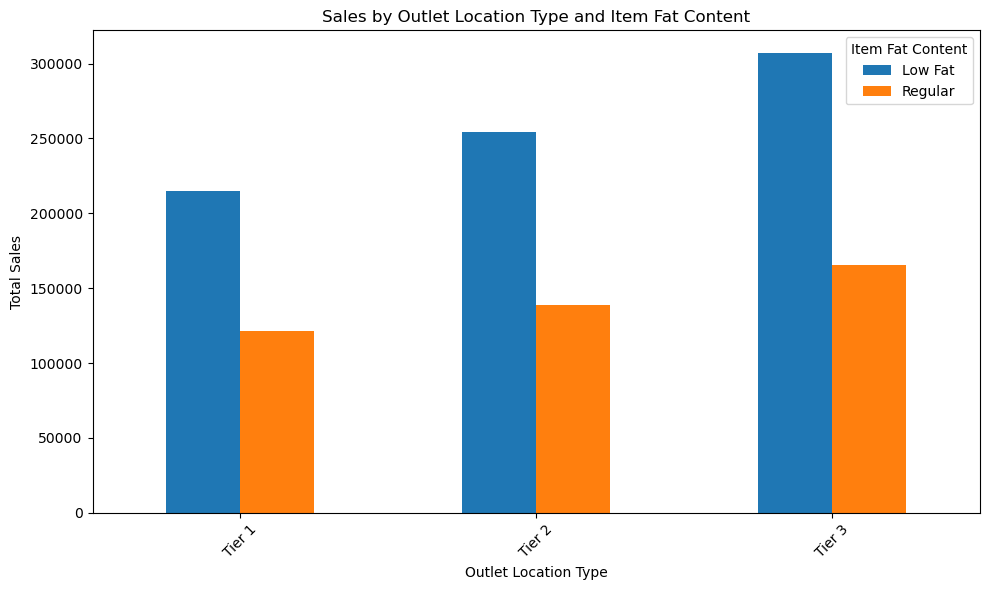

In [95]:
ax.plot(kind="bar", figsize=(10,6))

plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.title("Sales by Outlet Location Type and Item Fat Content")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Total Sales By Outlet Establishment

In [102]:
sales_by_year=df.groupby("Outlet Establishment Year")["Sales"].sum().sort_index()

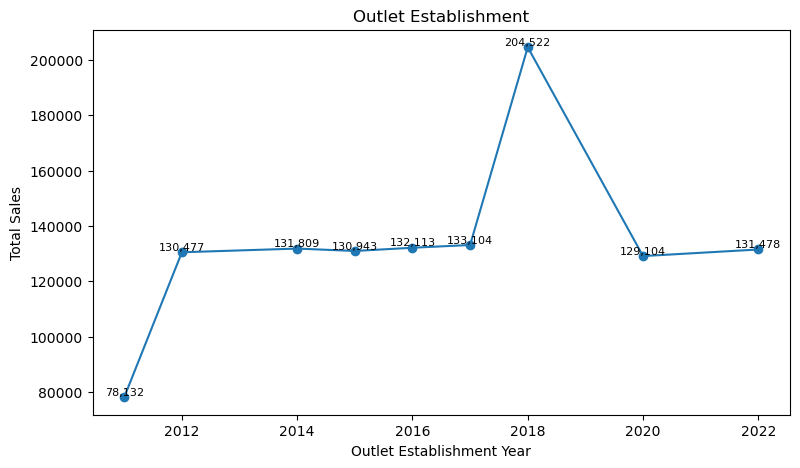

In [104]:
plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index,sales_by_year.values,marker="o",linestyle="-")

plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.title("Outlet Establishment")

for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y,f"{y:,.0f}",ha="center",va="bottom",fontsize=8)

plt.show()

### Sales By Outlet Size

In [107]:
sales_by_size=df.groupby("Outlet Size")["Sales"].sum()

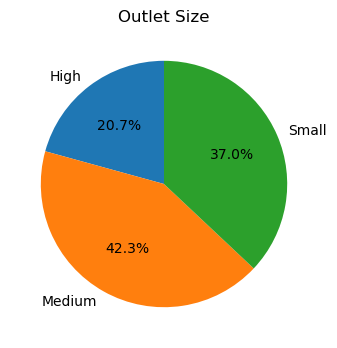

In [111]:
plt.figure(figsize=(4,4))
plt.pie(x=sales_by_size,labels=sales_by_size.index,autopct="%1.1f%%",startangle=90)
plt.title("Outlet Size")
plt.show()

### Sales By Outlet Location

In [114]:
sales_by_location=df.groupby("Outlet Location Type")["Sales"].sum().reset_index()
sales_by_location=sales_by_location.sort_values("Sales",ascending=False)

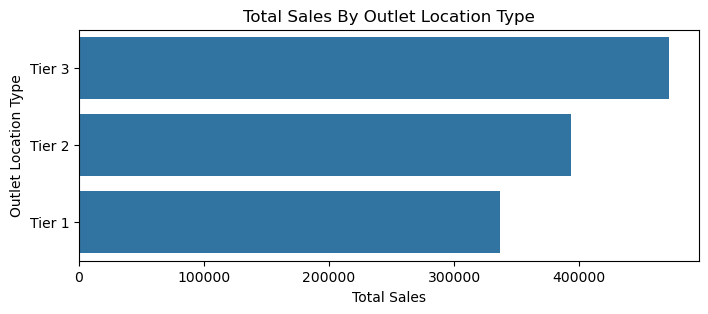

In [118]:
plt.figure(figsize=(8,3))
ax=sns.barplot(x=sales_by_location["Sales"],y=sales_by_location["Outlet Location Type"])
plt.title("Total Sales By Outlet Location Type")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Location Type")
plt.show()